In [ ]:
!pip install ultralytics

In [ ]:
import json
from ultralytics import YOLO
import ultralytics
import shutil
import random
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

pretrained poseモデルはセッターが50%くらいの確率でしか検出できない。  
そのためセッターの骨格をinputとしてファインチューニングする。

# check dataset format
coco8-poseデータセットに合わせてファインチューニング用のデータセットも作成するため、まずはcoco8-poseのフォーマットを確認

In [3]:
# yoloで期待されている形式を確認する
%cd /usr/local/lib/python3.12/dist-packages/ultralytics

/usr/local/lib/python3.12/dist-packages/ultralytics


In [4]:
!cat cfg/datasets/coco8-pose.yaml

# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# COCO8-pose dataset (first 8 images from COCO train2017) by Ultralytics
# Documentation: https://docs.ultralytics.com/datasets/pose/coco8-pose
# Example usage: yolo train data=coco8-pose.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── coco8-pose ← downloads here (1 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: coco8-pose # dataset root dir
train: images/train # train images (relative to 'path') 4 images
val: images/val # val images (relative to 'path') 4 images
test: # test images (optional)

# Keypoints
kpt_shape: [17, 3] # number of keypoints, number of dims (2 for x,y or 3 for x,y,visible)
flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]

# Classes
names:
  0: person

# Keypoint names per class
kpt_names:
  0:
    - nose
    - left_eye
    - right_eye
    - left_ear
    - right_ear
    - left_shoulder


In [5]:
!pwd

/usr/local/lib/python3.12/dist-packages/ultralytics


In [ ]:
# 以下を実行するとcoco8-pose.yamlがロードされるので確認のため実行（学習が始まったらやめる）

# Load a model
model = YOLO("yolo11n-pose.yaml")  # build a new model from YAML
model = YOLO("yolo11n-pose.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo11n-pose.yaml").load("yolo11n-pose.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(data="coco8-pose.yaml", epochs=100, imgsz=640)

In [ ]:
# ラベルは.txt形式だった、中身を確認
with open('/content/datasets/coco8-pose/labels/train/000000000036.txt') as f:
    line = f.read()
line

'0 0.671279 0.617945 0.645759 0.726859 0.519751 0.381250 2.000000 0.550936 0.348438 2.000000 0.488565 0.367188 2.000000 0.642412 0.354687 2.000000 0.488565 0.395313 2.000000 0.738046 0.526563 2.000000 0.446985 0.534375 2.000000 0.846154 0.771875 2.000000 0.442827 0.812500 2.000000 0.925156 0.964063 2.000000 0.507277 0.698438 2.000000 0.702703 0.942187 2.000000 0.555094 0.950000 2.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000\n'

In [8]:
len(line.split()) # 人/bboxの座標4/17骨格×（座標, 可視性）の56ラベル

56

# アノテーションした結果の確認
- coco-anotatorでアノテーションして出力されたjsonを`/content/setter_keypoints.json`とする

In [9]:
with open('/content/setter_keypoints.json') as f:
    skeltons_json = json.load(f)

In [10]:
skeltons_json.keys()

dict_keys(['images', 'categories', 'annotations'])

In [11]:
skeltons_json['annotations'][0]['keypoints'], len(skeltons_json['annotations'][0]['keypoints']) # これで骨格の座標を得ることができる

([0,
  0,
  0,
  555,
  767,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  552,
  798,
  2,
  0,
  0,
  0,
  539,
  770,
  2,
  0,
  0,
  0,
  537,
  729,
  2,
  0,
  0,
  0,
  553,
  879,
  2,
  0,
  0,
  0,
  544,
  953,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 51)

In [12]:
skeltons_json['annotations'][0]['bbox'], len(skeltons_json['annotations'][0]['bbox']) # これで骨格のbboxを得ることができる

([528, 720, 48, 311], 4)

# カスタムデータセット作成のためのディレクトリ作成

In [13]:
!pwd

/usr/local/lib/python3.12/dist-packages/ultralytics


In [14]:
%cd /content/

/content


In [15]:
!mkdir setter_skelton_dataset

In [16]:
!mkdir setter_skelton_dataset/images
!mkdir setter_skelton_dataset/labels

In [17]:
def coco_to_yolo_pose(
    bbox,          # [x, y, w, h] (pixel)
    keypoints,     # [x1,y1,v1, x2,y2,v2, ...]
    img_w=1080,
    img_h=1320,
    category_id=0,
):
    # --- bbox ---
    x, y, w, h = bbox
    # yolo datasetに合わせて正規化
    cx = round((x + w / 2) / img_w, 6)
    cy = round((y + h / 2) / img_h, 6)
    bw = round(w / img_w, 6)
    bh = round(h / img_h, 6)

    yolo_line = [
        category_id,
        cx, cy, bw, bh
    ]

    # --- keypoints ---
    for i in range(0, len(keypoints), 3):
        kx, ky, v = keypoints[i:i+3]

        if v == 0:
            # 未アノテーション
            yolo_line.extend([0.0, 0.0, 0])
        else:
            yolo_line.extend([
                round(kx / img_w, 6),
                round(ky / img_h, 6),
                int(v)
            ])
    # print(yolo_line)

    return yolo_line


In [ ]:
def generate_dataset_dir(json_path):
    with open(json_path) as f:
        skeltons_json = json.load(f)

    base_dir = '/content/setter_skelton_dataset'

    yaml_content = f"""
path: {base_dir}

train: images/train
val: images/val
test: images/test

# Keypoints
kpt_shape: [17, 3] # number of keypoints, number of dims (2 for x,y or 3 for x,y,visible)
flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]

# Classes
names:
    0: person

# Keypoint names per class
kpt_names:
    0:
        - nose
        - left_eye
        - right_eye
        - left_ear
        - right_ear
        - left_shoulder
        - right_shoulder
        - left_elbow
        - right_elbow
        - left_wrist
        - right_wrist
        - left_hip
        - right_hip
        - left_knee
        - right_knee
        - left_ankle
        - right_ankle
"""

    with open(f'{base_dir}/dataset.yaml', 'w') as f:
        f.write(yaml_content)

    # train / val / test ディレクトリ
    for split in ['train', 'val', 'test']:
        os.makedirs(f'{base_dir}/images/{split}', exist_ok=True)
        os.makedirs(f'{base_dir}/labels/{split}', exist_ok=True)

    skelton_anno = skeltons_json['annotations']
    images = skeltons_json['images']

    # シャッフル
    random.seed(42)
    random.shuffle(images)

    # split (7:1:2)
    n = len(images)

    train_idx = int(n * 0.7)
    val_idx = int(n * 0.8)

    train_images = images[:train_idx]
    val_images = images[train_idx:val_idx]
    test_images = images[val_idx:]

    print(
        f"Total: {len(images)}, "
        f"Train: {len(train_images)}, "
        f"Val: {len(val_images)}, "
        f"Test: {len(test_images)}"
    )

    for split, image_list in zip(
        ['train', 'val', 'test'],
        [train_images, val_images, test_images]
    ):

        for j in image_list:
            original_filename = j['file_name']
            new_filename = j['id']

            old_path = f'/content/drive/MyDrive/VNL2025/affined/{original_filename}'
            new_img_path = f'{base_dir}/images/{split}/{new_filename}.png'
            new_label_path = f'{base_dir}/labels/{split}/{new_filename}.txt'

            # 画像コピー
            shutil.copy(old_path, new_img_path)

            # annotation作成
            for anno in skelton_anno:
                if anno['image_id'] == new_filename:
                    try:
                        with open(new_label_path, mode='w') as f:
                            yolo_line = coco_to_yolo_pose(
                                anno['bbox'],
                                anno['keypoints']
                            )
                            line = ' '.join(map(str, yolo_line)) + '\n'
                            f.write(line)
                    except KeyError:
                        print(anno)

In [19]:
generate_dataset_dir('/content/setter_keypoints.json')

Total: 100, Train: 80, Val: 20


# ファインチューニング

In [ ]:
model = YOLO("yolo11n-pose.yaml")  # build a new model from YAML
model = YOLO("yolo11n-pose.pt")  # load a pretrained model (recommended for training)
results = model.train(data="/content/drive/MyDrive/VNL2025/dataset.yaml", epochs=250)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/VNL2025/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs

In [ ]:
# validation用の画像で結果を確認してみる（200eのベスト）
new_model = YOLO("/content/runs/pose/train-2/weights/best.pt")
# file_name = df_label.loc[working_id, 'file_name']
file_name = [f"/content/setter_skelton_dataset/images/test/{f}" for f in os.listdir('/content/setter_skelton_dataset/images/test')]
results = new_model(file_name)


0: 640x544 1 person, 4.6ms
1: 640x544 1 person, 4.6ms
2: 640x544 1 person, 4.6ms
3: 640x544 2 persons, 4.6ms
4: 640x544 2 persons, 4.6ms
5: 640x544 1 person, 4.6ms
6: 640x544 (no detections), 4.6ms
7: 640x544 1 person, 4.6ms
8: 640x544 1 person, 4.6ms
9: 640x544 1 person, 4.6ms
10: 640x544 1 person, 4.6ms
11: 640x544 1 person, 4.6ms
12: 640x544 1 person, 4.6ms
13: 640x544 1 person, 4.6ms
14: 640x544 1 person, 4.6ms
15: 640x544 1 person, 4.6ms
16: 640x544 1 person, 4.6ms
17: 640x544 1 person, 4.6ms
18: 640x544 1 person, 4.6ms
19: 640x544 1 person, 4.6ms
Speed: 2.6ms preprocess, 4.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 544)


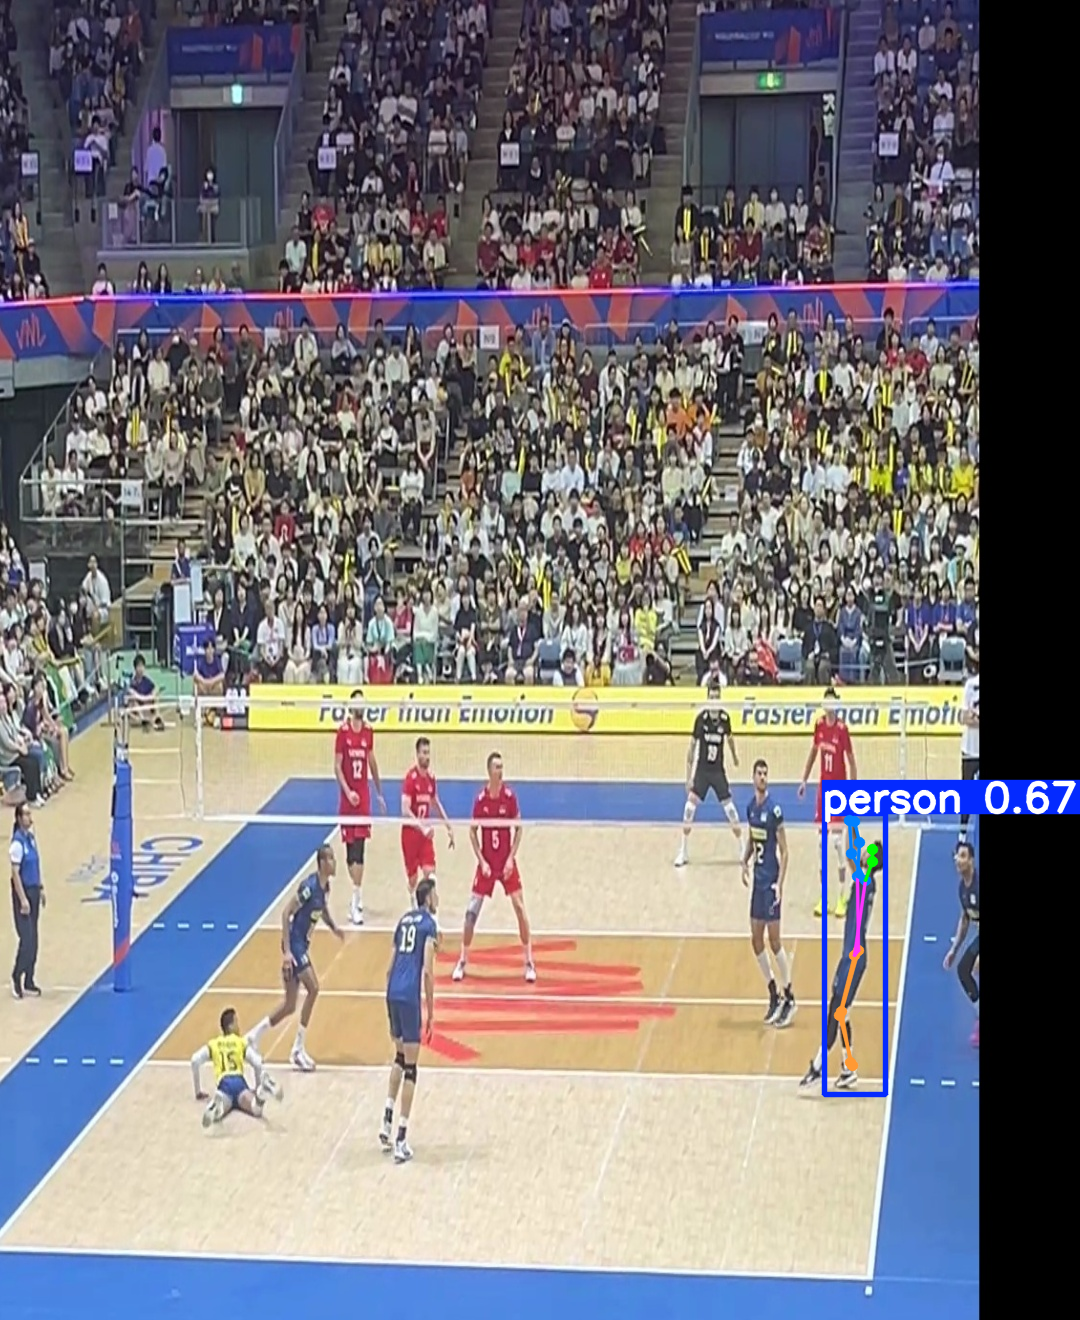

In [44]:
result = results[19]
result.show()  # display to screen
keypoints = result.keypoints

# スコアの確認

In [ ]:
# results.csvを読み込み
df = pd.read_csv("/content/drive/MyDrive/VNL2025/runs/pose/train/results.csv")

# 前後の空白を削除
df.columns = df.columns.str.strip()

# 3つのsubplotを縦に配置
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# =============================
# ① Train / Val Pose Loss
# =============================
axes[0].plot(
    df["epoch"],
    df["train/pose_loss"],
    label="train/pose_loss"
)

axes[0].plot(
    df["epoch"],
    df["val/pose_loss"],
    label="val/pose_loss"
)

axes[0].set_title("Train / Validation Pose Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Pose Loss")
axes[0].legend()
axes[0].grid(True)


# =============================
# ② mAP50(P)
# =============================
axes[1].plot(
    df["epoch"],
    df["metrics/mAP50(P)"],
    label="mAP50(P)"
)

axes[1].set_title("Pose mAP50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP50")
axes[1].legend()
axes[1].grid(True)


# =============================
# ③ mAP50-95(P)
# =============================
axes[2].plot(
    df["epoch"],
    df["metrics/mAP50-95(P)"],
    label="mAP50-95(P)"
)

axes[2].set_title("Pose mAP50-95")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("mAP50-95")
axes[2].legend()
axes[2].grid(True)


plt.tight_layout()
plt.savefig('plot.png')
plt.show()